In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [7]:
fish_df = pd.read_csv("/content/sample_data/Fish.csv")
fish_df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


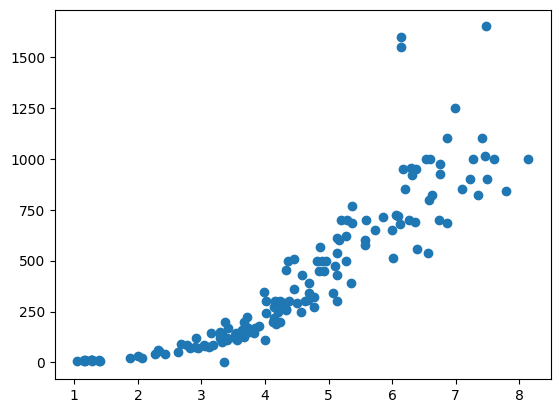

In [8]:
features = fish_df.filter(["Length1", "Length2", "Length3", "Height","Width"])
x_width = features["Width"]
y_weight = fish_df.filter(["Weight"])

plt.scatter(x_width, y_weight)

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline

In [17]:
degree = 3
X_train, X_test, y_train, y_test = train_test_split(x_width, y_weight, test_size=0.3, random_state=42)
model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=1.5, max_iter=1500, tol=0.1))
X_train_reshaped = np.array(X_train).reshape(-1,1)
y_train_reshaped = np.array(y_train).reshape(-1,1)

model.fit(X_train_reshaped, y_train_reshaped)


Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('ridge', Ridge(alpha=1.5, max_iter=1500, tol=0.1))])

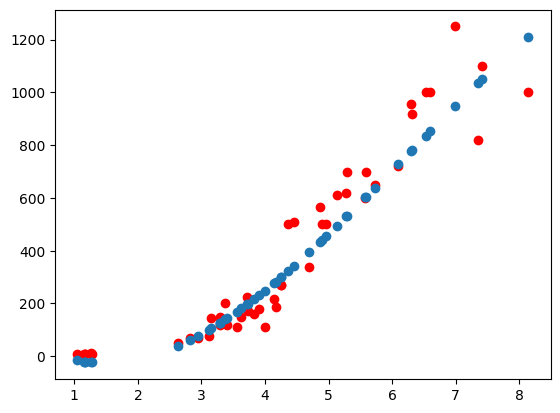

In [18]:
X_test_reshaped = np.array(X_test).reshape(-1,1)
y_weight_predictions = model.predict(X_test_reshaped)

plt.scatter(X_test, y_test, c="red")
plt.scatter(X_test, y_weight_predictions)

In [19]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_weight_predictions)

print(f"MAE = {mae}")

MAE = 73.56856306072577
